In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def extract_mat_file(filepath):
    """
    Extract BFData and ReconParams from a MATLAB v7.3 .mat file
    """
    # Load the file
    f = h5py.File(filepath, 'r')
    
    # Extract BFData
    BFData_dict = {}
    bfdata_group = f['BFData']
    
    # Get the complex arrays (IQ_xAM and IQ_xBmode)
    for array_name in ['IQ_xAM', 'IQ_xBMode']:
        if array_name in bfdata_group:
            # Load the raw data
            raw_data = bfdata_group[array_name][:]
            
            # Check the dtype and convert appropriately
            if 'complex' in str(raw_data.dtype):
                # Already complex type
                BFData_dict[array_name] = raw_data
            elif raw_data.dtype == np.float64 or raw_data.dtype == np.float32:
                # Real data only
                BFData_dict[array_name] = raw_data
            else:
                # Try to interpret as complex (MATLAB v7.3 stores complex as real+imag in structured dtype)
                try:
                    # Check if it's a structured array with real and imag fields
                    if raw_data.dtype.names is not None:
                        if 'real' in raw_data.dtype.names and 'imag' in raw_data.dtype.names:
                            complex_data = raw_data['real'] + 1j * raw_data['imag']
                            BFData_dict[array_name] = complex_data
                        else:
                            # Try to access fields dynamically
                            fields = list(raw_data.dtype.names)
                            if len(fields) >= 2:
                                complex_data = raw_data[fields[0]] + 1j * raw_data[fields[1]]
                                BFData_dict[array_name] = complex_data
                            else:
                                BFData_dict[array_name] = raw_data
                    else:
                        BFData_dict[array_name] = raw_data
                except:
                    BFData_dict[array_name] = raw_data
            
            print(f"Loaded {array_name} with shape: {BFData_dict[array_name].shape}, dtype: {BFData_dict[array_name].dtype}")
        elif array_name.lower() in [k.lower() for k in bfdata_group.keys()]:
            # Case-insensitive fallback
            actual_name = next(k for k in bfdata_group.keys() if k.lower() == array_name.lower())
            raw_data = bfdata_group[actual_name][:]
            
            # Same conversion logic
            if 'complex' in str(raw_data.dtype):
                BFData_dict[actual_name] = raw_data
            elif raw_data.dtype == np.float64 or raw_data.dtype == np.float32:
                BFData_dict[actual_name] = raw_data
            else:
                try:
                    if raw_data.dtype.names is not None:
                        if 'real' in raw_data.dtype.names and 'imag' in raw_data.dtype.names:
                            complex_data = raw_data['real'] + 1j * raw_data['imag']
                            BFData_dict[actual_name] = complex_data
                        else:
                            fields = list(raw_data.dtype.names)
                            if len(fields) >= 2:
                                complex_data = raw_data[fields[0]] + 1j * raw_data[fields[1]]
                                BFData_dict[actual_name] = complex_data
                            else:
                                BFData_dict[actual_name] = raw_data
                    else:
                        BFData_dict[actual_name] = raw_data
                except:
                    BFData_dict[actual_name] = raw_data
            
            print(f"Loaded {actual_name} with shape: {BFData_dict[actual_name].shape}, dtype: {BFData_dict[actual_name].dtype}")
    
    # Extract ReconParams
    ReconParams_dict = {}
    reconparams_group = f['ReconParams']
    
    for key in reconparams_group.keys():
        item = reconparams_group[key]
        data = item[:] if isinstance(item, h5py.Dataset) else item
        
        # Convert to scalar if it's a 1x1 array
        if isinstance(item, h5py.Dataset) and data.size == 1:
            data = data.item()
        # Remove any extra dimensions
        elif isinstance(data, np.ndarray) and data.size == 1:
            data = data.item()
        
        ReconParams_dict[key] = data

    ReconParams_dict['GridScaleX'] = ReconParams_dict['GridScaleZ'] #manual fix for now
    
    f.close()
    return BFData_dict, ReconParams_dict

In [2]:
data_dir = "./data/BioUSElective_20260506_JTLRYTAA/ST/"
filepath = data_dir + "data_20260506_164831_ST_5.9Vmat_20260506_165551.mat"

BFData, ReconParams = extract_mat_file(filepath)

Loaded IQ_xAM with shape: (260, 180), dtype: complex64
Loaded IQ_xBMode with shape: (260, 180), dtype: complex64


In [3]:
ReconParams.keys()

dict_keys(['Angles', 'DemodulationFrequency', 'DemodulationMode', 'FNumber', 'GridNx', 'GridNy', 'GridNz', 'GridOrigin', 'GridScaleX', 'GridScaleY', 'GridScaleZ', 'InterpolationMode', 'NFramesPerBatch', 'NRays', 'NSamplesPerTx', 'NTxPerFrame', 'PiezoXPos', 'PiezoYPos', 'PiezoZPos', 'PointSourceDistOffset', 'PointSourceX', 'PointSourceZ', 'SamplingFrequency', 'SequenceMode', 'SpeedOfSound', 'TXDistOffset', 'TimeCorrectionLens', 'TimeCorrectionStartDepth', 'TimeCorrectionWaveform', 'TransConnector'])

In [78]:
def plot_beamformed_image(BFData, ReconParams, mode='BMode', figsize=(10, 8),
                          cmap='bone', show_colorbar=True,
                          IMG_max=None, IMG_min=None, db_range=45, full_db_range=False):
    mode = mode.lower()
    if mode == 'am':
        iq_data = BFData.get('IQ_xAM')
        title = 'Log‑compressed IQ_xAM'
    elif mode == 'bmode':
        iq_data = BFData.get('IQ_xBMode')
        title = 'Log‑compressed IQ_xBMode'
    else:
        raise ValueError("mode must be 'AM' or 'BMode'")

    if iq_data is None:
        raise KeyError(f"Data for mode {mode} not found in BFData")

    envelope = np.abs(iq_data)
    envelope = envelope.T
    
    #log-compression
    if IMG_max is None:
        IMG_max = np.max(envelope)
    log_env = 20 * np.log10(envelope / IMG_max)        # 0 at max    
    if IMG_min is None:
        min_db = -db_range
    else:
        min_db = 20 * np.log10(IMG_min / IMG_max)
        print(min_db)
    
    if full_db_range==True:
        min_db = 20 * np.log10(np.min(envelope) / np.max(envelope))
        
    img_compressed = np.clip(log_env, min_db, 0)

    # Physical axes (meters -> mm)
    grid_origin = ReconParams['GridOrigin']
    grid_scale_x = ReconParams['GridScaleX'] 
    grid_scale_z = ReconParams['GridScaleZ']

    n_depth, n_lateral = iq_data.shape
    lateral_mm = (grid_origin[0] + np.arange(n_lateral) * grid_scale_x) * 1000
    depth_mm  = (grid_origin[2] + np.arange(n_depth)  * grid_scale_z) * 1000
    depth_mm = np.flip(depth_mm)
    
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(img_compressed,
                   extent=[lateral_mm[0], lateral_mm[-1], depth_mm[0], depth_mm[-1]],
                   aspect='equal',
                   cmap=cmap,
                   vmin=min_db, vmax=0)          # set dB range explicitly
    ax.set_ylabel('Depth (mm)')
    ax.set_xlabel('Lateral Position (mm)')
    ax.set_title(title)

    if show_colorbar:
        cbar = plt.colorbar(im, ax=ax, label='Amplitude (dB)')   # now labels dB correctly

    plt.tight_layout()
    return img_compressed, envelope, lateral_mm, depth_mm

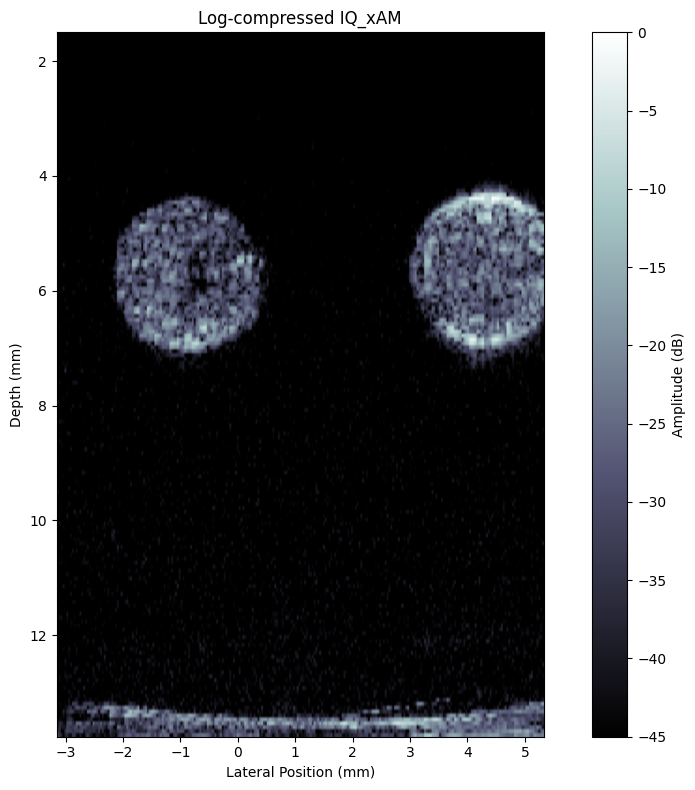

In [79]:
# Example usage:
img_log, envelope, lateral_mm, depth_mm = plot_beamformed_image(BFData, ReconParams, mode='AM', full_db_range=False)
# fig2, ax2 = plot_beamformed_image(BFData, ReconParams, mode='BMode')

In [82]:
import numpy as np
import matplotlib.pyplot as plt

def extract_subimage(image, depth_range, lateral_range, plot=True, db_range=45, IMG_min=None, IMG_max=None):
    """
    Extract a submatrix from a 2D image defined by index ranges and optionallyenvelope
    plot the original image with the submatrix region highlighted.

    Parameters
    ----------
    image : np.ndarray
        2D array of shape (depth, lateral) = (rows, columns).
    depth_range : tuple (int, int)
        Start and end indices for the depth (row) dimension. Supports
        both inclusive (closed) and half‑open intervals.
    lateral_range : tuple (int, int)
        Start and end indices for the lateral (column) dimension.
        Behaves similarly to depth_range.
    plot : bool, optional
        If True, display the original image with a red rectangle outlining
        the extracted submatrix. Default is True.

    Returns
    -------
    subimage : np.ndarray
        The extracted submatrix as a 2D array.
    """
    # Unpack ranges
    depth_start, depth_end = depth_range
    lat_start, lat_end = lateral_range

    # Inclusive interpretation: include both start and end indices
    depth_sub = slice(depth_start, depth_end + 1)
    lat_sub = slice(lat_start, lat_end + 1)

    subimage = image[depth_sub, lat_sub]

    #log-compression
    if IMG_max is None:
        IMG_max = np.max(image)
    log_env = 20 * np.log10(image / IMG_max)        # 0 at max    
    if IMG_min is None:
        min_db = -db_range
    else:
        min_db = 20 * np.log10(IMG_min / IMG_max)
    log_image = np.clip(log_env, min_db, 0)

    # Optional plotting
    if plot:
        plt.figure(figsize=(8, 6))
        # Plot the whole image
        plt.imshow(log_image, cmap='bone')
        plt.title("Original image with extracted region")

        # Draw rectangle: rectangle edges defined by (left, top, width, height)
        # Coordinates are in pixel indices.
        left = lat_start
        top = depth_start
        width = lat_end - lat_start + 1
        height = depth_end - depth_start + 1

        rect = plt.Rectangle((left, top), width, height,
                             linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)

        # Set aspect to auto to avoid distortion
        plt.gca().set_aspect(2.0)
        plt.show()

    return subimage


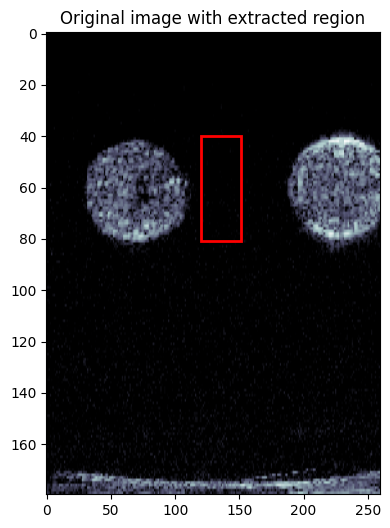

In [88]:
sub = extract_subimage(envelope, depth_range=(40, 80), lateral_range=(120, 150))

IMG_min = sub.mean()

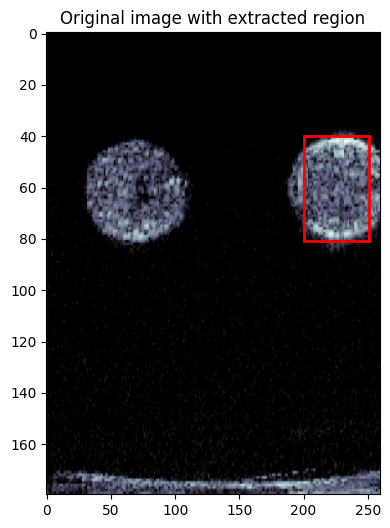

In [89]:
sub = extract_subimage(envelope, depth_range=(40, 80), lateral_range=(200, 250))

IMG_max = sub.max()

-50.788975


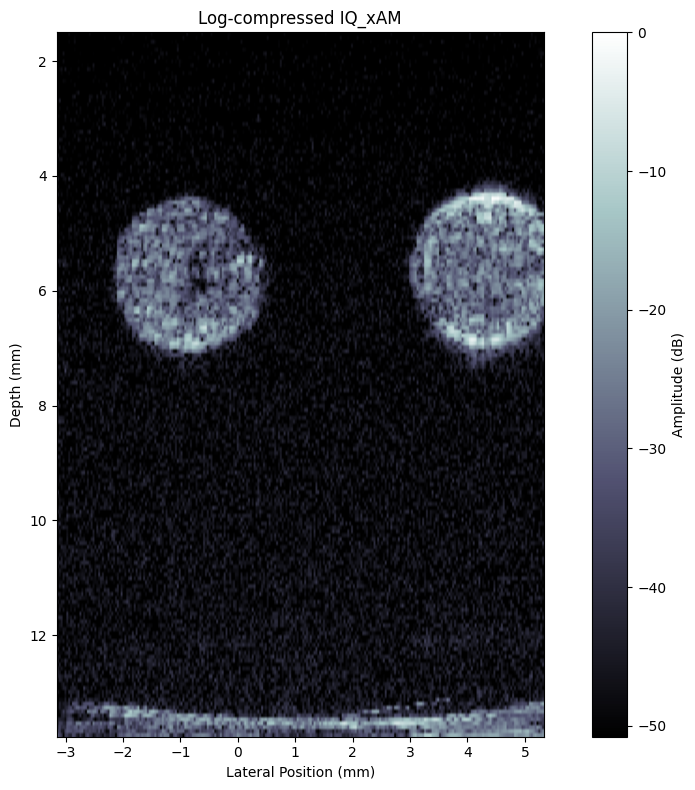

In [92]:
img_log, envelope, lateral_mm, depth_mm = plot_beamformed_image(BFData, ReconParams, mode='AM', IMG_min=IMG_min, IMG_max=IMG_max)

In [93]:
### collapse curves

In [96]:
import pandas as pd

# Provide the file path (adjust if needed)
file_path = "/home/dvallmanyapoch/Projects/biomol_elective/data/06052026_Jt_stripped_3_06052026.xlsx"

# Read all sheets into a dictionary of DataFrames
# header=0 means the first row of each sheet is the column header
# If some sheets have a different header row, adjust per sheet
sheets_dict = pd.read_excel(file_path, sheet_name=None, header=0)

# Iterate over each sheet and show its content
for sheet_name, df in sheets_dict.items():
    print(f"\n{'='*60}")
    print(f"Sheet: {sheet_name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(df.head())  # Show first few rows
    # To see the whole table: print(df.to_string())


Sheet: Parameters
Shape: (8, 2)
Columns: ['Parameters', 'Values']
          Parameters Values
0   Integration time    1.6
1  Equalization time      5
2       Max pressure   1000
3      Pressure step     20
4     Averaged scans     10

Sheet: Normalized Abs 500
Shape: (51, 2)
Columns: ['Pressure (kPa)', 'Absorbance 500nm']
   Pressure (kPa)  Absorbance 500nm
0             0.0          1.000000
1            20.0          0.981442
2            40.0          0.992908
3            60.0          0.979459
4            80.0          0.982179

Sheet: Raw Abs 500
Shape: (51, 2)
Columns: ['Pressure (kPa)', 'Absorbance 500nm']
   Pressure (kPa)  Absorbance 500nm
0             0.0          0.204926
1            20.0          0.206863
2            40.0          0.205666
3            60.0          0.207070
4            80.0          0.206786

Sheet: Full Data
Shape: (3648, 52)
Columns: ['Wavelength (nm)', '0', '20', '40', '60', '80', '100', '120', '140', '160', '180', '200', '220', '240', '260', '28

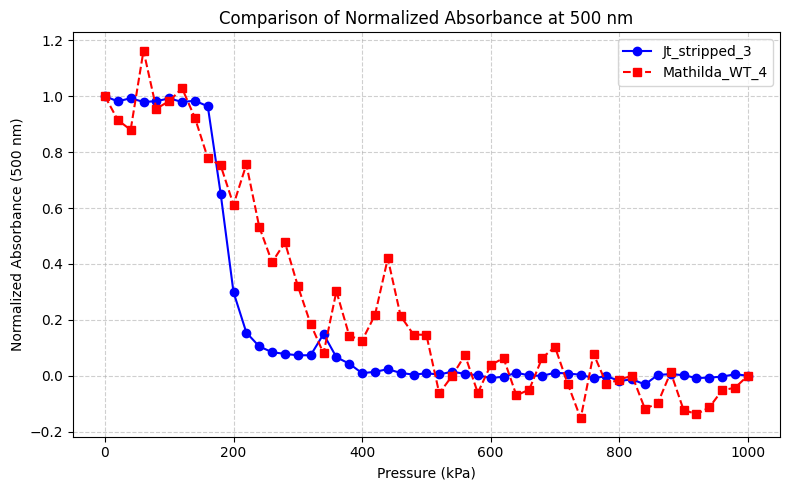

In [101]:
import pandas as pd
import matplotlib.pyplot as plt

# File path
file1 = "/home/dvallmanyapoch/Projects/biomol_elective/data/06052026_Jt_stripped_3_06052026.xlsx"
file2 = "/home/dvallmanyapoch/Projects/biomol_elective/data/06052026_Tudor_WT_5_06052026.xlsx"

# Read the "Normalized Abs 500" sheet from each file
df1 = pd.read_excel(file1, sheet_name="Normalized Abs 500")
df2 = pd.read_excel(file2, sheet_name="Normalized Abs 500")

# Plot both curves
plt.figure(figsize=(8, 5))
plt.plot(df1["Pressure (kPa)"], df1["Absorbance 500nm"], 
         marker='o', linestyle='-', color='blue', label="Jt_stripped_3")
plt.plot(df2["Pressure (kPa)"], df2["Absorbance 500nm"], 
         marker='s', linestyle='--', color='red', label="Mathilda_WT_4")

plt.xlabel("Pressure (kPa)")
plt.ylabel("Normalized Absorbance (500 nm)")
plt.title("Comparison of Normalized Absorbance at 500 nm")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()